In [1]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from quantumScarFunctions import *
from quantumScarsPlotting import *

In [9]:
N = 4
wd = 0.642570281124498
args = {"A": 0.1}
tlist = np.linspace(0, 1000, 1000)

H0, H1_list, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N, ham_disorder=[0, 0, 0],
                 random_seed=False, indv_qubit=True,
                 ohms=1.0, ds_dis=0)

dw = np.random.uniform(-0, 0, N)
omega_list = wd + dw
H = [H0]

for r in range(N):
    args[f"wd{r}"] = omega_list[r]
    H.append([H1_list[r], make_coeff(r)])

H = qt.QobjEvo(H, args=args)
psi_t = qt.sesolve(H, eigenstates[0], tlist, e_ops=[H0])
Rtau = np.array(np.real(psi_t.expect[0] - psi_t.expect[0][0]) / (eigenvalues[-1] - eigenvalues[0]))

In [4]:
H0, H1, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N, ham_disorder=[0, 0, 0], 
                random_seed=False, ds_detuning=0, 
                random_drive_strength=False, random_drive_freq=False,
                ohms=1.0)

args_full = {"A": 0.1, "omega": wd}
H = qt.QobjEvo([H0, [H1, coeff]], args=args_full)
psi_t = qt.sesolve(H, eigenstates[0], tlist, e_ops=[H0])
Rtau_vary = np.array(np.real(psi_t.expect[0] - psi_t.expect[0][0]) / (eigenvalues[-1] - eigenvalues[0]))

TypeError: get_scar_ham() got an unexpected keyword argument 'ds_detuning'

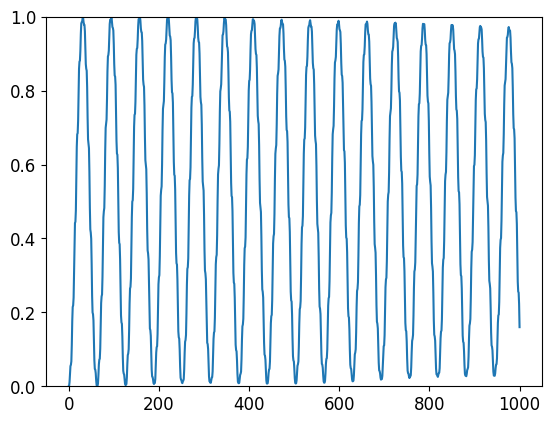

In [10]:
plt.plot(tlist, Rtau)
# plt.plot(tlist, Rtau_vary)
plt.ylim(0, 1)
plt.show()